### **1. Import Library**

Mengimpor semua library yang dibutuhkan untuk pengolahan data dan pembuatan model machine learning. Library yang digunakan meliputi pandas untuk manipulasi data, seaborn dan matplotlib untuk visualisasi, serta scikit-learn untuk ekstraksi fitur teks (TF-IDF) dan perhitungan *Cosine Similarity*.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, pickle, warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### **2. Load Dataset**

Dataset dimuat menggunakan `pd.read_csv()`. Pada tahap ini, kita juga mengecek jumlah total data wisata yang tersedia dalam dataset sebelum dilakukan penyaringan (filtering).

In [70]:
df = pd.read_csv("wisata_indonesia_clean.csv")
print("Jumlah Data Awal :", len(df))

Jumlah Data Awal : 1025


### **3. Data Understanding (Pemahaman Data)**

Untuk memahami struktur dataset, kita memanggil `df.info()` guna melihat tipe data setiap kolom. Selanjutnya, dilakukan pengecekan jumlah *missing value* (data yang kosong) pada masing-masing kolom dengan `df.isnull().sum()`.

In [71]:
print("Informasi Dataset")
print(df.info())

print("Missing Value")
print(df.isnull().sum())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kategori          1025 non-null   object 
 1   nama_wisata       1025 non-null   object 
 2   latitude          1025 non-null   float64
 3   longitude         1025 non-null   float64
 4   alamat            1025 non-null   object 
 5   provinsi          1025 non-null   object 
 6   kota_kabupaten    1007 non-null   object 
 7   nama_lengkap      1025 non-null   object 
 8   path_gambar       1025 non-null   object 
 9   deskripsi_bersih  998 non-null    object 
 10  Image_Path        1025 non-null   object 
dtypes: float64(2), object(9)
memory usage: 88.2+ KB
None
Missing Value
kategori             0
nama_wisata          0
latitude             0
longitude            0
alamat               0
provinsi             0
kota_kabupaten      18
nama_lengkap         0
path_gam

### **4. Filter Data untuk Wilayah Jawa Barat**

Karena fokus proyek ini adalah memberikan rekomendasi tempat wisata di wilayah Jawa Barat, maka data difilter berdasarkan kolom `provinsi` yang mengandung kata 'Jawa Barat'. Data yang sudah disaring kemudian disimpan dalam *dataframe* baru bernama `jabar`.

In [72]:
jabar = df[
    df['provinsi'].str.contains(
        'Jawa Barat',
        case=False,
        na=False
    )
].copy()
print("Jumlah Wisata Jawa Barat setelah Difilter:", len(jabar))

Jumlah Wisata Jawa Barat setelah Difilter: 105


### **5. Pengelompokan Kategori Wisata**

Data kategori wisata awal mungkin terlalu spesifik atau beragam. Oleh karena itu, kita membuat sebuah fungsi `kategori_wisata` untuk mengelompokkan ulang tempat wisata menjadi tiga kategori utama, yaitu: **Wisata Alam**, **Wisata Budaya**, dan **Wisata Rekreasi**.

In [73]:
def kategori_wisata(kategori):
    kategori = str(kategori).lower()

    if any(x in kategori for x in [
        'gunung','curug','pantai',
        'danau','bukit','hutan',
        'alam','geopark'
    ]):
        return 'Wisata Alam'

    elif any(x in kategori for x in [
        'museum','sejarah','budaya'
    ]):
        return 'Wisata Budaya'

    return 'Wisata Rekreasi'

jabar['kategori_baru'] = (
    jabar['kategori']
    .apply(kategori_wisata)
)
print(jabar['kategori_baru'].value_counts())

kategori_baru
Wisata Rekreasi    56
Wisata Alam        43
Wisata Budaya       6
Name: count, dtype: int64


### **6. Feature Engineering (Pembuatan Fitur Baru)**

Untuk sistem rekomendasi berbasis konten (*Content-Based Filtering*), kita memerlukan teks yang merepresentasikan setiap tempat wisata. Kita menggabungkan kolom `kategori` dan `deskripsi_bersih` menjadi satu kolom fitur baru yang dinamakan `content`.

In [74]:
jabar['content'] = (
    jabar['kategori'].fillna('')
    + ' ' +
    jabar['deskripsi_bersih'].fillna('')
)
display(jabar[['kategori', 'deskripsi_bersih', 'content']].head())

,kategori,deskripsi_bersih,content
7,air terjun,Deskripsi tidak ditemukan,air terjun Deskripsi tidak ditemukan
22,alun-alun,"Kota Bandung (bahasa Sunda: , Pegon: , Han...","alun-alun Kota Bandung (bahasa Sunda: , Peg..."
29,alun-alun,Kota Cirebon adalah salah satu kota yang berad...,alun-alun Kota Cirebon adalah salah satu kota ...
77,bukit,Kabupaten Kuningan (Aksara Sunda: ) adalah se...,bukit Kabupaten Kuningan (Aksara Sunda: ) ada...
124,cafe view,Deskripsi tidak ditemukan,cafe view Deskripsi tidak ditemukan


### **7. Text Cleaning (Pembersihan Teks)**

Teks pada kolom `content` perlu dibersihkan agar lebih optimal saat diekstraksi menggunakan algoritma TF-IDF. Proses *cleaning* meliputi pengubahan huruf menjadi huruf kecil (*case folding*), penghapusan karakter non-alfabet (simbol/angka), dan penghapusan spasi ganda.

In [75]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

jabar['content'] = (
    jabar['content']
    .apply(clean_text)
)
display(jabar[['kategori', 'deskripsi_bersih', 'content']].head())

,kategori,deskripsi_bersih,content
7,air terjun,Deskripsi tidak ditemukan,air terjun deskripsi tidak ditemukan
22,alun-alun,"Kota Bandung (bahasa Sunda: , Pegon: , Han...",alun alun kota bandung bahasa sunda pegon hanz...
29,alun-alun,Kota Cirebon adalah salah satu kota yang berad...,alun alun kota cirebon adalah salah satu kota ...
77,bukit,Kabupaten Kuningan (Aksara Sunda: ) adalah se...,bukit kabupaten kuningan aksara sunda adalah s...
124,cafe view,Deskripsi tidak ditemukan,cafe view deskripsi tidak ditemukan


### **8. Visualisasi Data Kategori Wisata**

Distribusi tempat wisata di Jawa Barat berdasarkan 3 kategori utama yang sudah dibuat sebelumnya. Kita menggunakan *count plot* dari `seaborn` untuk visualisasinya.

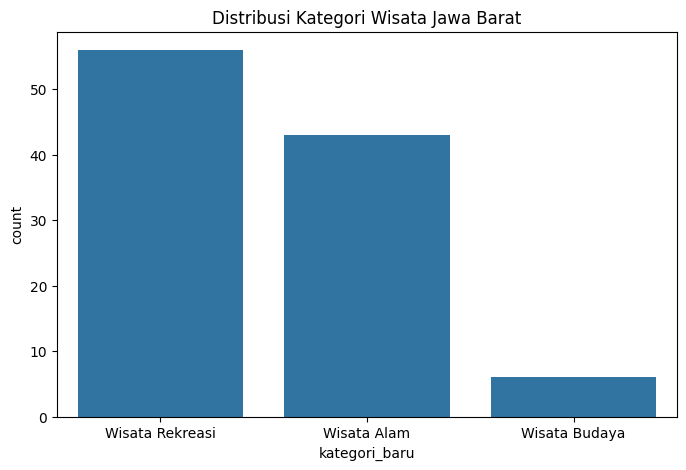

In [76]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=jabar,
    x='kategori_baru'
)
plt.title('Distribusi Kategori Wisata Jawa Barat')
plt.show()

### **9. Ekstraksi Fitur Teks dengan Algoritma TF-IDF**

Setelah teks dibersihkan, kita menggunakan `TfidfVectorizer` untuk mengubah teks (kolom `content`) ke dalam bentuk matriks angka berbobot. Matriks ini merepresentasikan seberapa penting sebuah kata dalam setiap deskripsi tempat wisata.

In [77]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    jabar['content']
)

print("Shape TF-IDF :", tfidf_matrix.shape)

Shape TF-IDF : (105, 667)


### **10. Algoritma Cosine Similarity**

Menghitung derajat kesamaan (*similarity*) antar tempat wisata. Kita menggunakan metrik *Cosine Similarity* pada matriks TF-IDF yang sudah dibuat. Hasil perhitungan ini berupa matriks kesamaan berukuran NxN (dimana N adalah jumlah wisata di Jawa Barat).

In [78]:
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

print("Shape Cosine Similarity :", cosine_sim.shape)

Shape Cosine Similarity : (105, 105)


### **11. Pembuatan Fungsi Sistem Rekomendasi**

Disini kita membuat fungsi `rekomendasi_wisata(nama_wisata, top_n=10)`. Fungsi ini bekerja dengan cara mencari indeks dari `nama_wisata` yang dicari, kemudian mengurutkan skor *cosine similarity* secara menurun, dan mengambil `top_n` tempat wisata dengan kemiripan tertinggi untuk direkomendasikan.

In [79]:
jabar = jabar.reset_index(drop=True)

indices = pd.Series(
    jabar.index,
    index=jabar['nama_wisata']
).drop_duplicates()

def rekomendasi_wisata(nama_wisata, top_n=10):

    idx = indices[nama_wisata]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    wisata_idx = [i[0] for i in sim_scores]

    return jabar.iloc[wisata_idx][[
        'nama_wisata',
        'kategori',
        'kategori_baru',
        'kota_kabupaten',
        'alamat'
    ]]

### **12. Pengujian dan Evaluasi**

Kita uji fungsi yang telah dibuat dengan memberikan satu contoh tempat wisata acuan dan menampilkan *Top 10 Rekomendasi*. Selanjutnya, kita juga mengukur performa sistem menggunakan metrik `Precision@K` yang membandingkan relevansi kategori dari tempat wisata yang direkomendasikan.

In [81]:
tempat = jabar['nama_wisata'].iloc[0]

print("Wisata Acuan: ", tempat)

hasil = rekomendasi_wisata(
    tempat,
    top_n=10
)

print("Top 10 Rekomendasi")

display(hasil)

def precision_at_k(
    rekomendasi,
    kategori_target,
    k=10
):
    relevan = rekomendasi[
        rekomendasi['kategori_baru']
        == kategori_target
    ]
    return len(relevan) / k

kategori_target = jabar[
    jabar['nama_wisata'] == tempat
]['kategori_baru'].values[0]

precision = precision_at_k(
    hasil,
    kategori_target,
    10
)

print("Hasil Evaluasi")
print("Precision@10 =", round(precision,3))

Wisata Acuan:  Air Terjun Curug Dengdeng
Top 10 Rekomendasi


,nama_wisata,kategori,kategori_baru,kota_kabupaten,alamat
19,Gunung Puntang,gunung,Wisata Alam,Garut,"Gunung Puntang, Garut, Jawa Barat, Jawa, Indon..."
54,Curug Cibereum,wisata alam,Wisata Alam,Cianjur,"Curug Cibereum, Cianjur, Jawa Barat, Jawa, Ind..."
58,Curug Cipeuteuy,wisata alam,Wisata Alam,Karawang,"Aliran Sungai Curug Cigeuntis, Kp. Parakan Bad..."
60,Curug Nangka,wisata alam,Wisata Alam,Kab Bogor,"Curug Nangka, Tamansari, Kab Bogor, Jawa Barat..."
63,Devoyage Bogor,wisata alam,Wisata Alam,Bogor,"Devoyage Bogor, Jalan Pabuaran, Bogor Selatan,..."
98,The Lodge Maribaya,wisata alam,Wisata Alam,Bandung Barat,"The Lodge Maribaya, Jalan Cibodas Maribaya, 15..."
100,Situ Ciburuy,wisata alam,Wisata Alam,Bandung Barat,"Situ Ciburuy, Cempakamekar, Bandung Barat, Jaw..."
72,Kampung Sampireun,wisata edukasi,Wisata Rekreasi,Sukakarya,"Kampung Sampireun Resort & Spa, Jalan Sukakary..."
76,Pusat Konservasi Elang Kamojang,wisata edukasi,Wisata Rekreasi,Sukakarya,"Pusat Konservasi Elang Kamojang, Maya Coola, S..."
95,Rainbow Garden Lembang,wisata tematik,Wisata Rekreasi,Bandung Barat,"Rainbow Garden, Lembang, Bandung Barat, Jawa B..."


Hasil Evaluasi
Precision@10 = 0.3


### **13. Visualisasi Hasil dan Simpan Model**

Langkah terakhir, kita memvisualisasikan proporsi kategori dari hasil rekomendasi yang diberikan. Setelah semuanya selesai, model yang sudah dilatih (objek TF-IDF dan matriks Cosine Similarity) disimpan dalam file `.pkl` (pickle) agar bisa digunakan kembali (deployment) di kemudian hari.

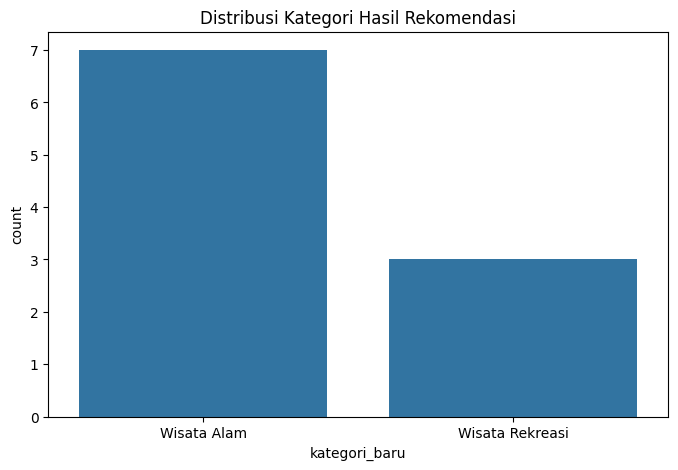

tfidf_model.pkl
cosine_similarity.pkl


In [82]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=hasil,
    x='kategori_baru'
)
plt.title(
    'Distribusi Kategori Hasil Rekomendasi'
)
plt.show()

pickle.dump(
    tfidf,
    open('tfidf_model.pkl','wb')
)

pickle.dump(
    cosine_sim,
    open('cosine_similarity.pkl','wb')
)

print("tfidf_model.pkl")
print("cosine_similarity.pkl")